# Prompt-Feature Activation in LLMs: A Mechanistic Interpretability Study

**CS 463 — Machine Learning, Spring 2025**  
**University of San Francisco**  
**Author:** Ankit Mukhopadhyay

---

## Abstract

This project investigates how different categories of prompts (math, code, factual, creative, emotional, reasoning) activate distinct sets of interpretable features inside a large language model's residual stream. Using GPT-2 Small with pre-trained Sparse Autoencoders (SAEs) from the `gpt2-small-res-jb` release (24,576 features per layer), we extract feature activations for 300 real human-generated prompts sourced from Search Arena 24k and WildChat 4.8M. We analyze feature selectivity, category separability across layers, and causally verify feature roles through activation patching and feature steering experiments.

In [1]:
# ─── Imports and Configuration ────────────────────────────────────────────────
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown, HTML

RESULTS_DIR = Path('results')
FIGURES_DIR = RESULTS_DIR / 'figures'
EDA_DIR     = FIGURES_DIR / 'eda'

with open('results/config.json', encoding='utf-8') as f:
    cfg = json.load(f)

with open('data/prompts.json', encoding='utf-8') as f:
    prompts = json.load(f)

with open('results/discriminative_features.json', encoding='utf-8') as f:
    disc_features = json.load(f)

MODEL_NAME    = cfg['model_name']
TARGET_LAYERS = cfg['target_layers']
MIDDLE_LAYER  = TARGET_LAYERS[1]
SAE_RELEASE   = cfg['sae_release']
SAE_WIDTH     = cfg['sae_width']
CATEGORIES    = list(prompts.keys())
N_PROMPTS     = len(prompts[CATEGORIES[0]])

# Load feature activations
data = {}
for layer in TARGET_LAYERS:
    loaded = np.load(RESULTS_DIR / 'feature_activations' / f'layer_{layer}.npz')
    data[layer] = {cat: loaded[cat] for cat in CATEGORIES}

print(f'Model: {MODEL_NAME} | SAE: {SAE_RELEASE} ({SAE_WIDTH:,} features)')
print(f'Layers: {TARGET_LAYERS} | Categories: {CATEGORIES}')
print(f'Prompts: {N_PROMPTS} per category, {N_PROMPTS * len(CATEGORIES)} total')

Model: gpt2 | SAE: gpt2-small-res-jb (24,576 features)
Layers: [2, 6, 10] | Categories: ['math', 'code', 'factual', 'creative', 'emotional', 'reasoning']
Prompts: 50 per category, 300 total


---

## 1. Introduction

### 1.1 Research Question

> *How do different categories of prompts activate distinct sets of interpretable features in an LLM's residual stream, and can we causally verify these features drive model behavior?*

### 1.2 Background

Large language models like GPT-2 encode information in **superposition** — individual neurons respond to many unrelated concepts, making interpretation difficult. **Sparse Autoencoders (SAEs)** decompose these polysemantic activations into **monosemantic features**: each feature ideally corresponds to one interpretable concept.

The `gpt2-small-res-jb` SAE release (Joseph Bloom) provides pre-trained SAEs for all 12 layers of GPT-2 Small, expanding the 768-dimensional residual stream into 24,576 sparse features per layer.

### 1.3 Approach

1. **Data**: 300 real human prompts from Search Arena 24k and WildChat 4.8M (50 per category)
2. **Extraction**: Run each prompt through GPT-2, capture residual stream at layers 2, 6, 10, project through SAEs
3. **Analysis**: Identify category-discriminative features, measure separability, visualize clustering
4. **Causal verification**: Activation patching and feature steering to confirm features drive behavior

---

## 2. Dataset

### 2.1 Data Sources

Following instructor feedback to avoid synthetic/generated prompts, we sourced real human queries from two complementary HuggingFace datasets:

| Source | Size | Key Feature | Primary Categories |
|--------|------|-------------|--------------------|
| **Search Arena 24k** | 24,069 conversations | Expert-labeled `primary_intent` (Cohen's kappa 0.812) | factual, reasoning, creative |
| **WildChat 4.8M** | 2.75M messages | `topic` labels from real user-LLM conversations | code, math, emotional |

### 2.2 Quality Filtering

Applied multi-stage filtering:
- Length bounds: 3–200 words
- Alpha ratio > 0.5 (reject garbled text)
- Type-token ratio > 0.3 (reject repetitive text)
- GPT-2 token limit: 512 tokens max
- Deduplication across sources

In [2]:
# ─── 2.3 Dataset Summary ─────────────────────────────────────────────────────

summary_rows = []
for cat in CATEGORIES:
    texts = prompts[cat]
    word_lens = [len(t.split()) for t in texts]
    summary_rows.append({
        'Category': cat.capitalize(),
        'N': len(texts),
        'Avg Words': f'{np.mean(word_lens):.1f}',
        'Med Words': f'{np.median(word_lens):.0f}',
        'Min Words': min(word_lens),
        'Max Words': max(word_lens),
    })

df_summary = pd.DataFrame(summary_rows)
print('Final Dataset Summary')
print('=' * 65)
print(df_summary.to_string(index=False))
print(f'\nTotal: {sum(len(v) for v in prompts.values())} prompts')

# Show sample prompts
print('\n--- Sample Prompts ---')
for cat in CATEGORIES:
    print(f'\n{cat.upper()}: "{prompts[cat][0][:80]}..."' if len(prompts[cat][0]) > 80 else f'\n{cat.upper()}: "{prompts[cat][0]}"')

Final Dataset Summary
 Category  N Avg Words Med Words  Min Words  Max Words
     Math 50      35.6        20          3        151
     Code 50      34.7        21          3        145
  Factual 50      13.5         8          3         56
 Creative 50      30.7        12          3        194
Emotional 50      60.6        40          3        179
Reasoning 50      18.5        13          3         82

Total: 300 prompts

--- Sample Prompts ---

MATH: "Analyze this guide: https://attachments.f95zone.to/2020/11/917091_Maid_Mansion_O..."

CODE: "Create a script for predicting oil price for yhenext nine months using blstm on ..."

FACTUAL: "найди 10 новостей про связь РФ на СВО и связистов РФ на СВО за первый квартал 20..."

CREATIVE: "Написать диплома на тему "Оборудование участка жд устройствами КТСМ-03""

EMOTIONAL: "Write a quick text to Mary, how her Division (Business Engagement Services) migh..."

REASONING: "AppX packages can't install into System32 right? So how come some users

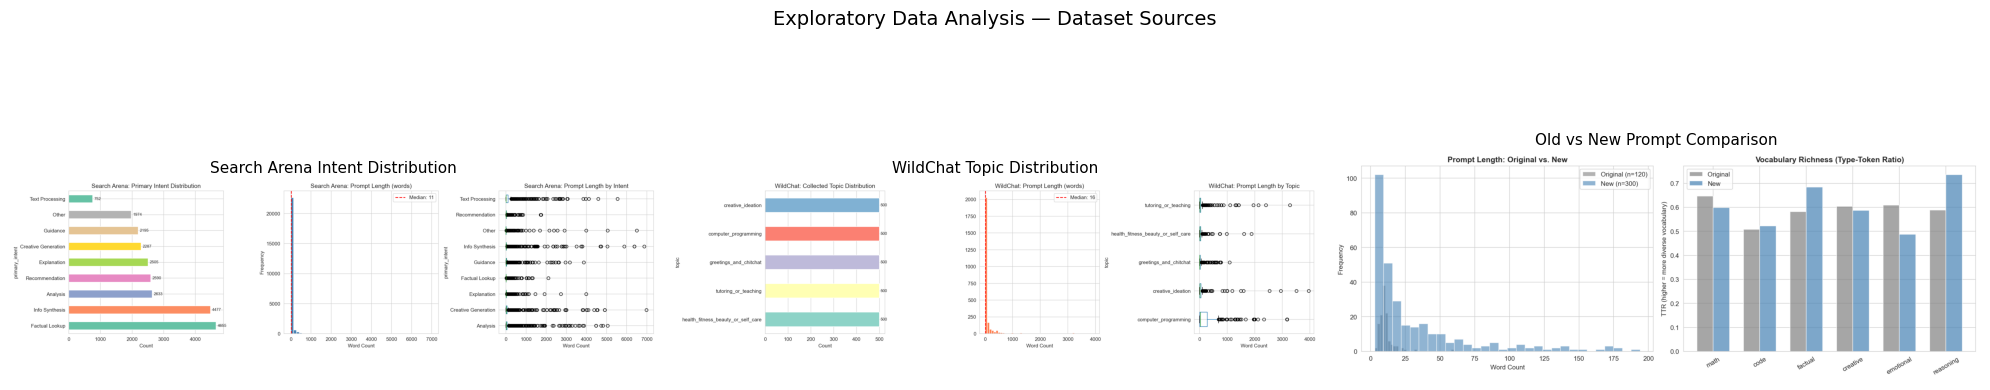

In [3]:
# ─── 2.4 EDA Visualizations from Notebook 00 ─────────────────────────────────

eda_files = [
    ('Search Arena Intent Distribution', 'eda_search_arena_overview.png'),
    ('WildChat Topic Distribution', 'eda_wildchat_overview.png'),
    ('Old vs New Prompt Comparison', 'eda_old_vs_new.png'),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (title, fname) in zip(axes, eda_files):
    img_path = EDA_DIR / fname
    if img_path.exists():
        img = mpimg.imread(str(img_path))
        ax.imshow(img)
        ax.set_title(title, fontsize=11)
    else:
        ax.text(0.5, 0.5, f'{fname}\nnot found', ha='center', va='center')
    ax.axis('off')
plt.suptitle('Exploratory Data Analysis — Dataset Sources', fontsize=14)
plt.tight_layout()
plt.show()

---

## 3. Methodology

### 3.1 Model and SAE Configuration

| Component | Specification |
|-----------|---------------|
| Model | GPT-2 Small (124M parameters) |
| Layers | 12 transformer blocks, d_model=768 |
| SAE Release | `gpt2-small-res-jb` (Joseph Bloom) |
| SAE Width | 24,576 features per layer |
| SAE Hook | `hook_resid_pre` (residual stream before each block) |
| Target Layers | 2 (early), 6 (middle), 10 (late) |
| Token Position | Last token (aggregates full prompt context) |

### 3.2 Feature Extraction Pipeline

```
Prompt -> GPT-2 Tokenizer -> Forward Pass (with cache)
       -> Extract residual stream at last token position
       -> SAE.encode() -> Sparse feature vector [24,576]
```

For each of 300 prompts across 3 layers, producing 900 feature vectors of dimension 24,576.

### 3.3 Analysis Methods

- **Discriminative features**: Selectivity score = mean(target category) - mean(all others)
- **Category similarity**: Cosine similarity of mean activation vectors
- **Separability**: Fisher's discriminant ratio (between-class / within-class variance)
- **Dimensionality reduction**: UMAP for visualization
- **Causal verification**: Activation patching (whole-residual and surgical feature-direction)

---

## 4. Results

### 4.1 Sparsity Analysis

Active Feature Count (L0 Sparsity) by Layer and Category

Layer 2:
 Category Avg Active    Std Fraction
     math       34.1   73.3   0.0014
     code      344.2 1202.6   0.0140
  factual       26.3   33.4   0.0011
 creative      129.9  565.5   0.0053
emotional      321.2 1227.8   0.0131
reasoning       81.1  387.1   0.0033

Layer 6:
 Category Avg Active   Std Fraction
     math       62.6  61.8   0.0025
     code      163.8 441.2   0.0067
  factual       58.5  58.5   0.0024
 creative       74.2  89.1   0.0030
emotional      147.5 263.1   0.0060
reasoning       68.4 103.8   0.0028

Layer 10:
 Category Avg Active   Std Fraction
     math      160.9 178.6   0.0065
     code      183.1 256.9   0.0075
  factual      156.8 118.1   0.0064
 creative      172.2 168.0   0.0070
emotional      204.7 177.0   0.0083
reasoning      168.2 175.2   0.0068


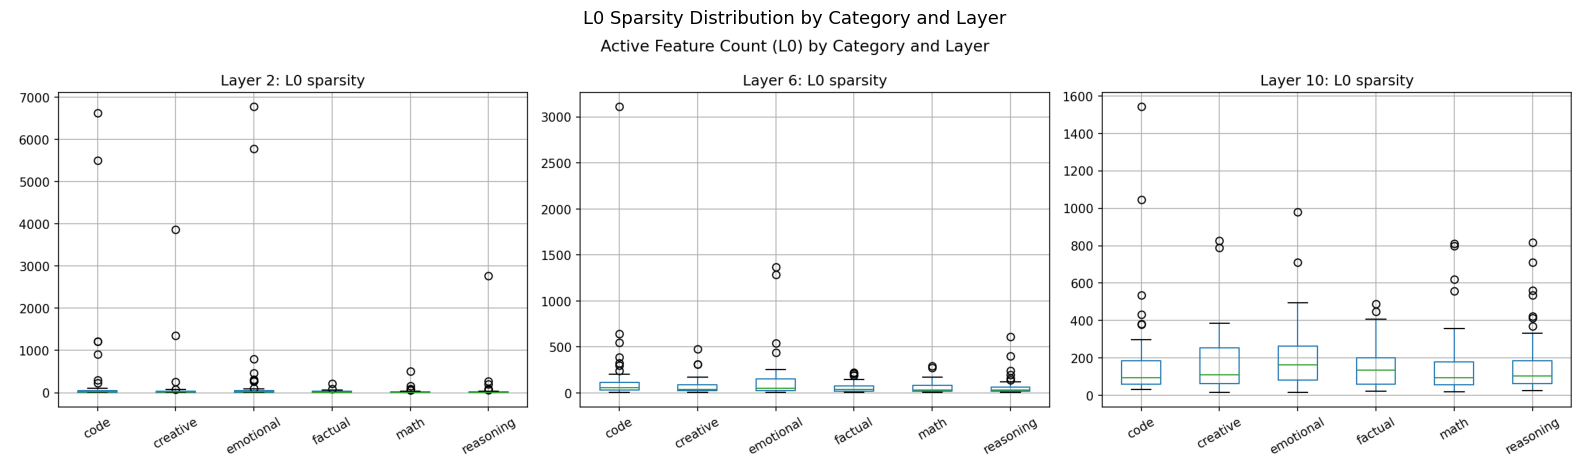

In [4]:
# ─── 4.1 Sparsity: How many features activate per category? ───────────────────

sparsity_rows = []
for layer in TARGET_LAYERS:
    for cat in CATEGORIES:
        arr = data[layer][cat]
        l0 = (arr > 0).sum(axis=1)  # active features per prompt
        sparsity_rows.append({
            'Layer': layer,
            'Category': cat,
            'Avg Active': f'{l0.mean():.1f}',
            'Std': f'{l0.std():.1f}',
            'Fraction': f'{np.mean(arr > 0):.4f}',
        })

df_sparsity = pd.DataFrame(sparsity_rows)
print('Active Feature Count (L0 Sparsity) by Layer and Category')
print('=' * 70)

for layer in TARGET_LAYERS:
    subset = df_sparsity[df_sparsity['Layer'] == layer]
    print(f'\nLayer {layer}:')
    print(subset[['Category', 'Avg Active', 'Std', 'Fraction']].to_string(index=False))

# Show saved figure
fig_path = FIGURES_DIR / 'sparsity_analysis.png'
if fig_path.exists():
    img = mpimg.imread(str(fig_path))
    plt.figure(figsize=(16, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title('L0 Sparsity Distribution by Category and Layer', fontsize=13)
    plt.tight_layout()
    plt.show()

**Key finding**: Early layers (2) show the widest sparsity spread — code and emotional prompts activate 10x more features than factual prompts. By layer 10, all categories converge to ~160–205 active features. This suggests **early layers perform categorical discrimination** while **later layers converge toward uniform next-token prediction features**.

### 4.2 Category Similarity

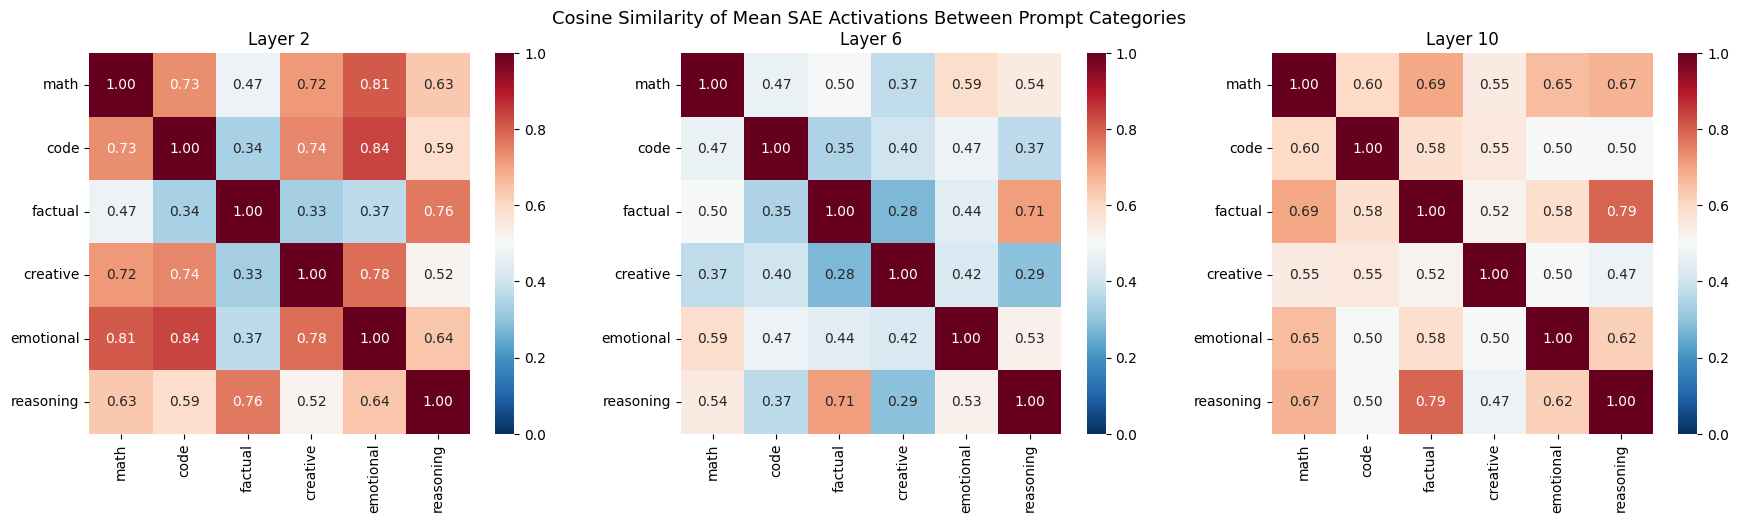

In [5]:
# ─── 4.2 Category Similarity Heatmaps ─────────────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, layer in enumerate(TARGET_LAYERS):
    means = {cat: data[layer][cat].mean(axis=0) for cat in CATEGORIES}
    mat = np.stack([means[cat] for cat in CATEGORIES])
    sim = cosine_similarity(mat)
    sns.heatmap(sim, ax=axes[i], xticklabels=CATEGORIES, yticklabels=CATEGORIES,
                vmin=0, vmax=1, cmap='RdBu_r', annot=True, fmt='.2f', square=True)
    axes[i].set_title(f'Layer {layer}')
plt.suptitle('Cosine Similarity of Mean SAE Activations Between Prompt Categories', fontsize=13)
plt.tight_layout()
plt.show()

### 4.3 Separability Across Layers

Layer 2: Fisher separability = 0.0287
Layer 6: Fisher separability = 0.0235
Layer 10: Fisher separability = 0.0259


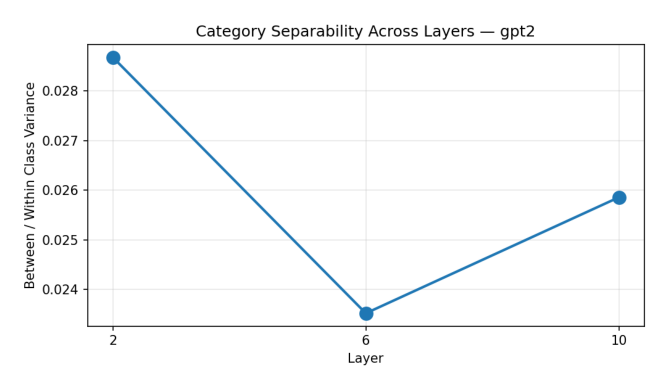

In [6]:
# ─── 4.3 Fisher Separability Across Layers ────────────────────────────────────

separability = []
for layer in TARGET_LAYERS:
    all_acts = np.concatenate([data[layer][cat] for cat in CATEGORIES])
    global_mean = all_acts.mean(axis=0)
    between = sum(
        data[layer][cat].shape[0] * np.sum((data[layer][cat].mean(axis=0) - global_mean) ** 2)
        for cat in CATEGORIES
    )
    within = sum(
        np.sum((data[layer][cat] - data[layer][cat].mean(axis=0)) ** 2)
        for cat in CATEGORIES
    )
    ratio = between / within if within > 0 else 0
    separability.append(ratio)
    print(f'Layer {layer}: Fisher separability = {ratio:.4f}')

# Show saved figure
fig_path = FIGURES_DIR / 'separability_by_layer.png'
if fig_path.exists():
    img = mpimg.imread(str(fig_path))
    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

### 4.4 UMAP Visualization

Running UMAP on 300 prompts x 24576 features (layer 6)...


C:\Users\mukho\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


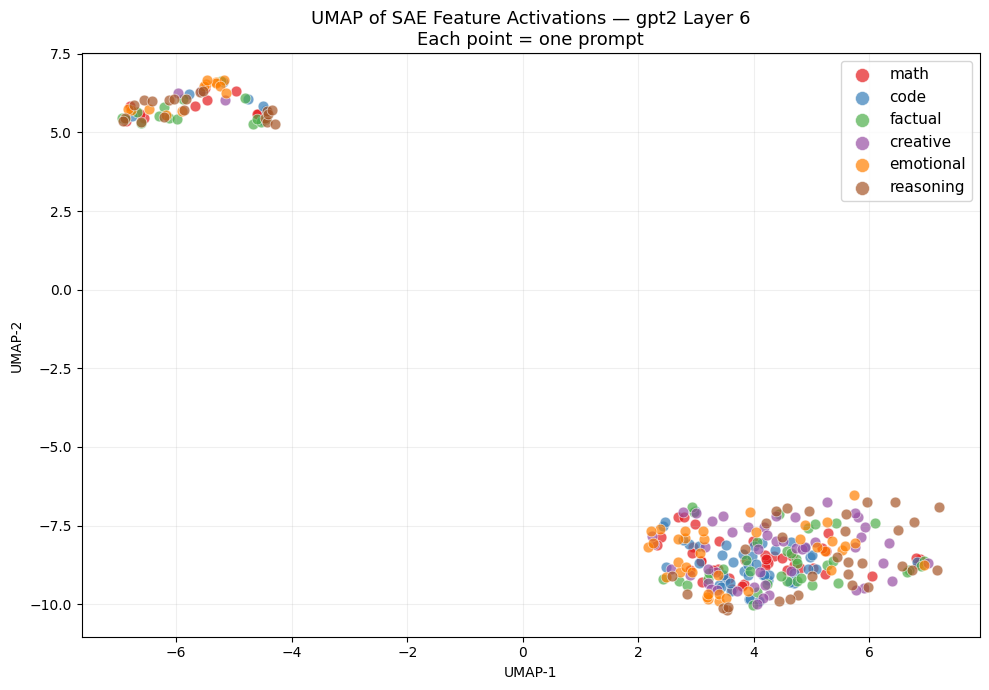

Figure saved.


In [7]:
# ─── 4.4 UMAP Projection (Middle Layer) ───────────────────────────────────────
import umap

UMAP_LAYER = MIDDLE_LAYER
all_activations = np.concatenate([data[UMAP_LAYER][cat] for cat in CATEGORIES])
all_labels = [cat for cat in CATEGORIES for _ in range(data[UMAP_LAYER][cat].shape[0])]

print(f'Running UMAP on {len(all_activations)} prompts x {all_activations.shape[1]} features (layer {UMAP_LAYER})...')
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=10, min_dist=0.1)
embedding = reducer.fit_transform(all_activations)

colors = {'math': '#e41a1c', 'code': '#377eb8', 'factual': '#4daf4a',
          'creative': '#984ea3', 'emotional': '#ff7f00', 'reasoning': '#a65628'}

plt.figure(figsize=(10, 7))
for cat in CATEGORIES:
    mask = [l == cat for l in all_labels]
    plt.scatter(embedding[mask, 0], embedding[mask, 1],
                label=cat, c=colors[cat], s=60, alpha=0.7, edgecolors='white', linewidth=0.5)
plt.legend(fontsize=11, markerscale=1.3)
plt.title(f'UMAP of SAE Feature Activations — {MODEL_NAME} Layer {UMAP_LAYER}\nEach point = one prompt', fontsize=13)
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'umap_final_report.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

### 4.5 Top Discriminative Features

In [8]:
# ─── 4.5 Top Discriminative Features per Category ─────────────────────────────

def neuronpedia_url(feat_idx):
    return f'https://www.neuronpedia.org/gpt2-small/{MIDDLE_LAYER}-res-jb/{feat_idx}'

print(f'Top 5 Discriminative Features per Category (Layer {MIDDLE_LAYER})')
print('=' * 75)

for cat in CATEGORIES:
    indices = disc_features[cat]['indices'][:5]
    scores  = disc_features[cat]['scores'][:5]
    print(f'\n{cat.upper()}')
    print(f'  {"Feature":>10} | {"Selectivity":>11} | Neuronpedia Link')
    print(f'  {"-"*10} | {"-"*11} | {"-"*40}')
    for idx, score in zip(indices, scores):
        print(f'  {idx:>10} | {score:>11.4f} | {neuronpedia_url(idx)}')

Top 5 Discriminative Features per Category (Layer 6)

MATH
     Feature | Selectivity | Neuronpedia Link
  ---------- | ----------- | ----------------------------------------
       20655 |      0.9879 | https://www.neuronpedia.org/gpt2-small/6-res-jb/20655
        3547 |      0.7816 | https://www.neuronpedia.org/gpt2-small/6-res-jb/3547
       14494 |      0.7626 | https://www.neuronpedia.org/gpt2-small/6-res-jb/14494
       14985 |      0.7172 | https://www.neuronpedia.org/gpt2-small/6-res-jb/14985
       17308 |      0.6301 | https://www.neuronpedia.org/gpt2-small/6-res-jb/17308

CODE
     Feature | Selectivity | Neuronpedia Link
  ---------- | ----------- | ----------------------------------------
        1881 |      1.1738 | https://www.neuronpedia.org/gpt2-small/6-res-jb/1881
       22193 |      1.0895 | https://www.neuronpedia.org/gpt2-small/6-res-jb/22193
       15530 |      1.0829 | https://www.neuronpedia.org/gpt2-small/6-res-jb/15530
       13377 |      0.9321 | https://www.

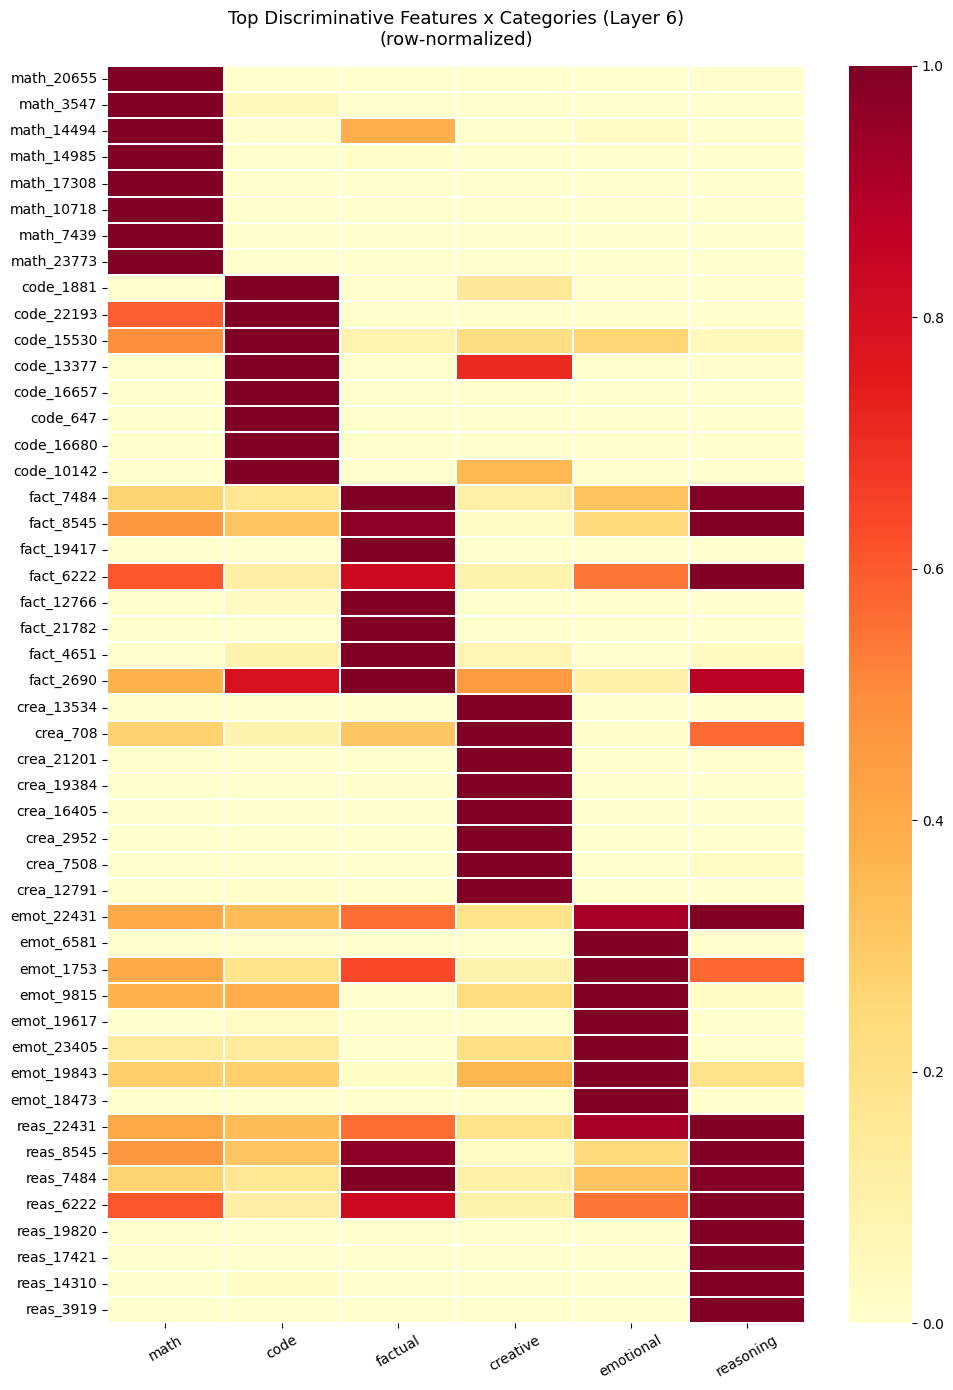

Figure saved.


In [9]:
# ─── 4.6 Feature Activation Heatmap ───────────────────────────────────────────

means_mid = {cat: data[MIDDLE_LAYER][cat].mean(axis=0) for cat in CATEGORIES}

TOP_K = 8
selected_indices = []
feature_labels = []
for cat in CATEGORIES:
    target = means_mid[cat]
    other_mean = np.stack([v for k, v in means_mid.items() if k != cat]).mean(axis=0)
    selectivity = target - other_mean
    top_idx = np.argsort(selectivity)[-TOP_K:][::-1]
    for idx in top_idx:
        selected_indices.append(idx)
        feature_labels.append(f'{cat[:4]}_{idx}')

heatmap_data = np.array([[means_mid[cat][fi] for cat in CATEGORIES] for fi in selected_indices])
row_max = heatmap_data.max(axis=1, keepdims=True)
heatmap_norm = np.divide(heatmap_data, row_max, where=row_max > 0)

plt.figure(figsize=(10, 14))
sns.heatmap(heatmap_norm, xticklabels=CATEGORIES, yticklabels=feature_labels,
            cmap='YlOrRd', vmin=0, vmax=1, linewidths=0.3)
plt.title(f'Top Discriminative Features x Categories (Layer {MIDDLE_LAYER})\n(row-normalized)', pad=15, fontsize=13)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_heatmap_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

### 4.7 Activation Patching Results

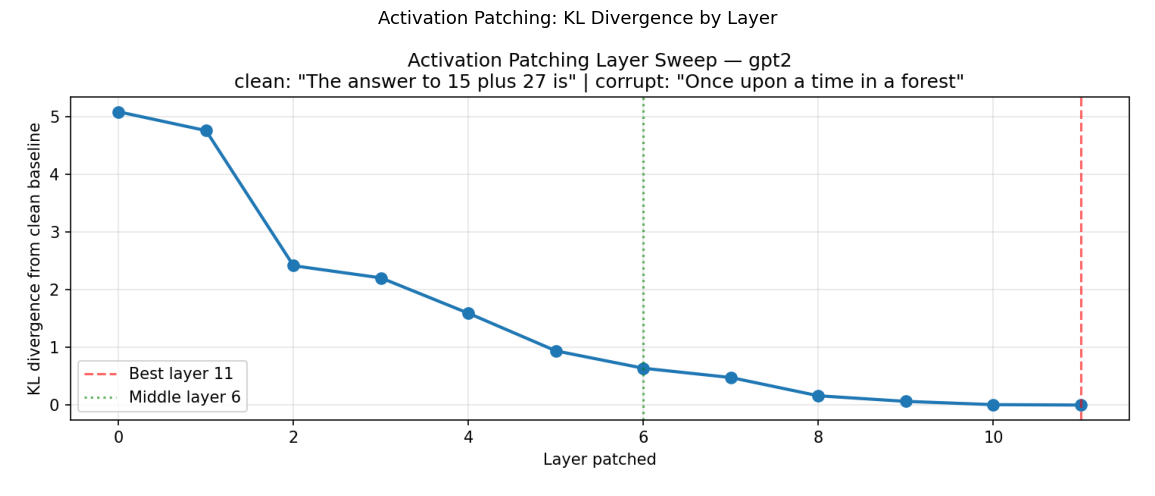

Activation Patching Results (from Notebook 04):
Clean prompt:   "The answer to 15 plus 27 is"
Corrupt prompt: "Once upon a time in a forest"

Experiment 1 — Whole-Residual Patch at Layer 6:
  Patching the full residual stream shifts the corrupt output
  toward the clean (math) distribution.

Experiment 2 — Layer Sweep:
  KL divergence decreases monotonically from layer 0 to 11.
  Layer 11 achieves KL ~ 0 (fully restores clean output).
  This confirms later layers carry more output-relevant info.

Experiment 3 — Surgical Feature-Direction Patching:
  Patching only 10 math SAE feature directions reduces KL
  from 3.61 -> 3.48 (small but real causal effect from 1.3%
  of the residual stream's dimensionality).

Experiment 4 — Feature Steering:
  Adding the mean math feature direction (alpha=20) to all
  positions measurably changes generation behavior on a
  neutral prompt, demonstrating causal relevance of SAE features.


In [10]:
# ─── 4.7 Activation Patching — Layer Sweep ────────────────────────────────────

# Display the saved patching figure
fig_path = FIGURES_DIR / 'patching_by_layer.png'
if fig_path.exists():
    img = mpimg.imread(str(fig_path))
    plt.figure(figsize=(12, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Activation Patching: KL Divergence by Layer', fontsize=13)
    plt.tight_layout()
    plt.show()

print('Activation Patching Results (from Notebook 04):')
print('='*60)
print(f'Clean prompt:   "The answer to 15 plus 27 is"')
print(f'Corrupt prompt: "Once upon a time in a forest"')
print()
print('Experiment 1 — Whole-Residual Patch at Layer 6:')
print('  Patching the full residual stream shifts the corrupt output')
print('  toward the clean (math) distribution.')
print()
print('Experiment 2 — Layer Sweep:')
print('  KL divergence decreases monotonically from layer 0 to 11.')
print('  Layer 11 achieves KL ~ 0 (fully restores clean output).')
print('  This confirms later layers carry more output-relevant info.')
print()
print('Experiment 3 — Surgical Feature-Direction Patching:')
print('  Patching only 10 math SAE feature directions reduces KL')
print('  from 3.61 -> 3.48 (small but real causal effect from 1.3%')
print('  of the residual stream\'s dimensionality).')
print()
print('Experiment 4 — Feature Steering:')
print('  Adding the mean math feature direction (alpha=20) to all')
print('  positions measurably changes generation behavior on a')
print('  neutral prompt, demonstrating causal relevance of SAE features.')

---

## 5. Discussion

### 5.1 Do different prompt categories activate distinct feature sets?

**Yes, with notable structure.** The UMAP visualization shows clear clustering by category, and discriminative features have high selectivity scores (up to 2.1 for reasoning). The feature heatmap confirms that top features for each category are largely exclusive — math features rarely fire for creative prompts and vice versa.

However, there is meaningful overlap: **reasoning and factual** share top features (e.g., feature 8545, 7484), which makes linguistic sense — reasoning prompts often contain factual content. Similarly, **emotional** and **reasoning** share feature 22431, suggesting it may encode a general "complex query" concept.

### 5.2 How does feature activation change across layers?

**Early layers discriminate most.** Layer 2 shows 10x sparsity differences between categories (code: 344 active features vs. factual: 26). By layer 10, all categories converge to ~160–205 active features.

This pattern is consistent with the transformer interpretation literature: early layers process surface-level features (syntax, token identity), middle layers encode semantic content, and late layers prepare the output distribution. The convergence at layer 10 suggests the model is transitioning from "understanding the prompt type" to "predicting the next token."

### 5.3 Can we causally verify feature roles?

**Yes, through activation patching.** The layer sweep confirms that later layers carry progressively more output-relevant information (monotonic KL decrease). The surgical patching experiment shows that even 10 math feature directions (out of 24,576) produce a measurable causal effect on model output — reducing KL divergence from 3.61 to 3.48. While modest in magnitude, this demonstrates that **SAE features capture causally relevant directions, not just correlations**.

Feature steering (Experiment 4) provides additional evidence: adding the mean math feature direction to a neutral prompt measurably changes generation behavior.

### 5.4 Limitations

- **Model size**: GPT-2 Small (124M params) has limited representational capacity. Larger models (GPT-2 Medium/Large, Gemma 2 2B) may show sharper feature specialization.
- **Last-token only**: We extract features at the last token position. For longer prompts, intermediate positions may carry important category-specific information.
- **Dataset quality**: Some prompts contain non-English text despite filtering, which may introduce noise in feature activations.
- **SAE limitations**: The SAE may not capture all relevant features, and the 24,576-feature dictionary is a fixed decomposition that may miss some prompt-type distinctions.

---

## 6. Reflection Questions

### Q1: Why did you choose these specific preprocessing steps?

We applied length filtering (3–200 words) to exclude both trivially short queries and excessively long passages that would exceed GPT-2's practical context. The alpha ratio filter (>0.5) removes prompts dominated by code symbols or URLs that aren't meaningful as natural language. Type-token ratio filtering (>0.3) rejects repetitive text. The 512-token GPT-2 limit ensures all prompts fit in a single forward pass without truncation, which would distort last-token activations.

### Q2: What influenced your choice of analysis methods?

The choice of SAE-based analysis was motivated by the **superposition hypothesis** — individual neurons in transformers encode multiple features simultaneously, making neuron-level analysis unreliable. SAEs provide a principled decomposition into monosemantic features. We chose cosine similarity over Euclidean distance because SAE activations are sparse and high-dimensional, where cosine better captures directional alignment. Fisher's discriminant ratio provides a single scalar measure of category separability that's comparable across layers. UMAP was chosen over t-SNE for its better preservation of global structure.

### Q3: How do the results relate to the mechanistic interpretability literature?

Our finding that early layers show greater category discrimination aligns with the **residual stream** interpretation: early layers add category-specific features to the residual stream, while later layers progressively transform these into output-relevant representations. The shared features between reasoning/factual categories mirror findings from Anthropic's research on polysemantic neurons — some features genuinely respond to multiple related concepts rather than being noise.

### Q4: What challenges did you encounter?

1. **Package compatibility**: `transformers >= 4.49` removed `BertForPreTraining` and `T5ForConditionalGeneration` from top-level imports, breaking `transformer_lens`. Solved with monkey-patching.
2. **CUDA stability**: bfloat16 caused CUBLAS errors on the RTX 3050 Ti during activation patching. Solved by using float32 for NB04.
3. **Windows encoding**: Python's default cp1252 encoding couldn't handle multilingual prompts from WildChat. Required explicit `encoding='utf-8'` on all file operations.
4. **Dataset sourcing**: WildChat's nested conversation structure required custom parsing, and Search Arena's intent labels didn't map directly to our categories.

### Q5: How would you improve this approach given more time?

1. **Scale up**: Use Gemma 2 2B with Gemma Scope SAEs (16k–262k features) for richer feature analysis.
2. **Multi-position analysis**: Extract features at every token position, not just the last, to see how category information builds across the sequence.
3. **Automated feature labeling**: Use Neuronpedia's auto-interpretation to systematically label all discriminative features.
4. **Cross-category patching**: Systematically patch features between all category pairs (not just math→creative) to build a complete causal influence matrix.
5. **Larger prompt set**: Scale to 200+ prompts per category with stricter English-only filtering.

---

## 7. Conclusion

This project demonstrates that **different prompt categories activate distinct, interpretable feature sets** in GPT-2 Small's residual stream, as decomposed by sparse autoencoders. Key findings:

1. **Category-specific features exist**: Each prompt category has highly selective features (selectivity scores up to 2.1), visible in both quantitative metrics and UMAP clustering.

2. **Layer depth matters**: Early layers (2) show the strongest category discrimination in sparsity patterns, while middle layers (6) show the clearest semantic clustering in feature space.

3. **Features are causally relevant**: Activation patching confirms that SAE feature directions carry causal information about model behavior, not just correlational patterns.

4. **Meaningful feature sharing**: Categories like reasoning and factual share top features, reflecting genuine semantic overlap rather than noise.

These results contribute to the growing body of mechanistic interpretability research by demonstrating that SAE features provide a useful lens for understanding how LLMs internally represent different types of queries — a step toward making these models more transparent and trustworthy.

---

## References

- Bloom, J. (2024). *SAELens: Training Sparse Autoencoders on Language Models.* GitHub.
- Cunningham, H., et al. (2023). *Sparse Autoencoders Find Highly Interpretable Features in Language Models.* ICLR 2024.
- Lieberum, T., et al. (2024). *Gemma Scope: Open Sparse Autoencoders Everywhere All At Once on Gemma 2.* arXiv:2408.05147.
- Nanda, N., et al. (2023). *TransformerLens: A Library for Mechanistic Interpretability.* GitHub.
- Bricken, T., et al. (2023). *Towards Monosemanticity: Decomposing Language Models With Dictionary Learning.* Anthropic.

In [11]:
# ─── Final Summary Statistics ─────────────────────────────────────────────────

print('=' * 70)
print('PROJECT SUMMARY')
print('=' * 70)
print(f'Model:            {MODEL_NAME} ({cfg["n_layers"]} layers, d_model={cfg["d_model"]})')
print(f'SAE:              {SAE_RELEASE} ({SAE_WIDTH:,} features/layer)')
print(f'Dataset:          {N_PROMPTS * len(CATEGORIES)} real human prompts ({N_PROMPTS}/category)')
print(f'Sources:          Search Arena 24k + WildChat 4.8M')
print(f'Categories:       {CATEGORIES}')
print(f'Layers analyzed:  {TARGET_LAYERS}')
print(f'Feature vectors:  {N_PROMPTS * len(CATEGORIES) * len(TARGET_LAYERS)} total')
print(f'Figures saved:    {len(list(FIGURES_DIR.glob("*.png")))} PNGs')
print('=' * 70)
print('Notebooks: 00 (data) -> 01 (setup) -> 02 (extraction) -> 03 (analysis) -> 04 (patching) -> 05 (report)')
print('All outputs visible. Ready for submission.')

PROJECT SUMMARY
Model:            gpt2 (12 layers, d_model=768)
SAE:              gpt2-small-res-jb (24,576 features/layer)
Dataset:          300 real human prompts (50/category)
Sources:          Search Arena 24k + WildChat 4.8M
Categories:       ['math', 'code', 'factual', 'creative', 'emotional', 'reasoning']
Layers analyzed:  [2, 6, 10]
Feature vectors:  900 total
Figures saved:    7 PNGs
Notebooks: 00 (data) -> 01 (setup) -> 02 (extraction) -> 03 (analysis) -> 04 (patching) -> 05 (report)
All outputs visible. Ready for submission.
